=== DISTRIBUTION DES CLASSES ===
TRAIN :
label
NEUTROPHIL    2663
EOSINOPHIL    2494
MONOCYTE      1136
LYMPHOCYTE     971
Name: count, dtype: int64

VAL :
label
NEUTROPHIL    333
EOSINOPHIL    311
MONOCYTE      142
LYMPHOCYTE    122
Name: count, dtype: int64

=== VÉRIFICATION TAILLE ===
Exemple d'image : LY_191979.jpg
Taille réelle : (360, 363)


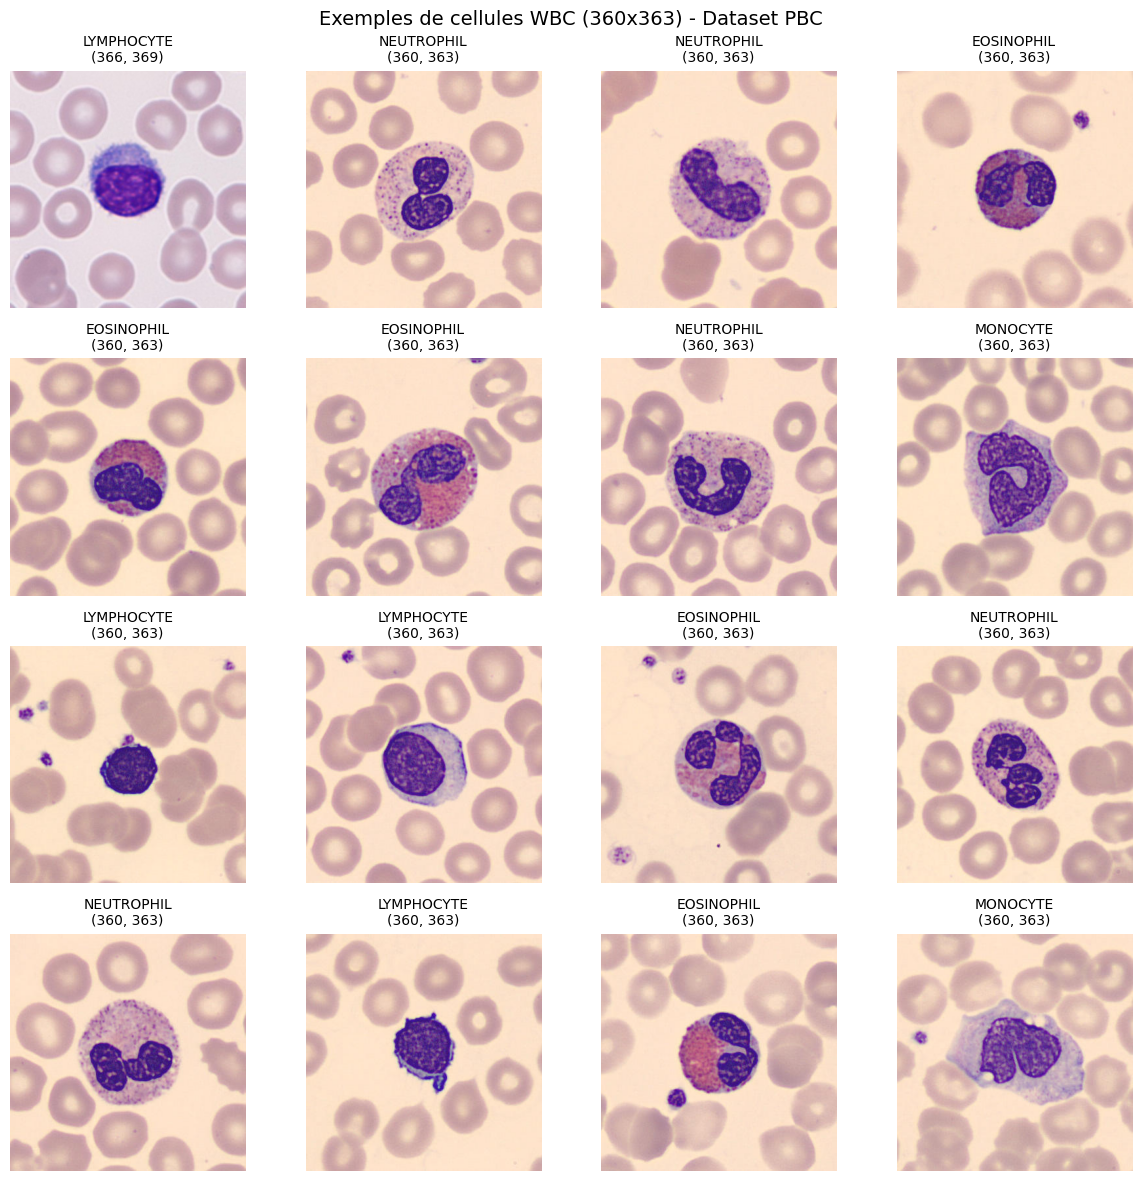


=== VÉRIFICATION DATASET PYTORCH ===
Taille du dataset train : 7264
Dimension du tensor après transformations (Resize 224) : torch.Size([3, 224, 224])


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import sys
from PIL import Image
import random

sys.path.append(str(Path.cwd().parent))
from src.data.classification_dataset import WBCCellDataset


PROJECT_ROOT = Path("..")
SPLIT_DIR = PROJECT_ROOT / "data" / "splits"

train_csv = SPLIT_DIR / "classification_train.csv"
val_csv = SPLIT_DIR / "classification_val.csv"

train_df = pd.read_csv(train_csv)
val_df = pd.read_csv(val_csv)


print("=== DISTRIBUTION DES CLASSES ===")
print("TRAIN :")
print(train_df['label'].value_counts())
print("\nVAL :")
print(val_df['label'].value_counts())


sample_img_path = train_df.iloc[0]['image_path']
img = Image.open(sample_img_path)
print(f"\n=== VÉRIFICATION TAILLE ===")
print(f"Exemple d'image : {Path(sample_img_path).name}")
print(f"Taille réelle : {img.size}")  


fig, axes = plt.subplots(4, 4, figsize=(12, 12))
class_names = ['NEUTROPHIL', 'MONOCYTE', 'LYMPHOCYTE', 'EOSINOPHIL']

for i, ax in enumerate(axes.flat):
    
    row = train_df.sample(1).iloc[0]
    img_path = row['image_path']
    label = row['label']
    
    img = Image.open(img_path).convert('RGB')
    ax.imshow(img)
    ax.set_title(f"{label}\n{img.size}", fontsize=10)
    ax.axis('off')

plt.suptitle("Exemples de cellules WBC (360x363) - Dataset PBC", fontsize=14)
plt.tight_layout()
plt.show()


dataset = WBCCellDataset(train_csv, is_train=True)
print(f"\n=== VÉRIFICATION DATASET PYTORCH ===")
print(f"Taille du dataset train : {len(dataset)}")
img_tensor, label = dataset[0]
print(f"Dimension du tensor après transformations (Resize 224) : {img_tensor.shape}")  